<a href="https://colab.research.google.com/github/Arczisork/Sztuczna-inteligencja/blob/main/sztuczna_lab_zad2b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)



2.19.0


In [2]:
observations = 500000
xs = np.random.uniform(low=-10,high=10,size=(observations,1))
zs = np.random.uniform(low=-10,high=10,size=(observations,1))
inputs=np.column_stack((xs,zs))
print(inputs.shape)


(500000, 2)


In [3]:
noise = np.random.uniform(low=-1,high=1,size=(observations,1))
targets = 2*xs - 3*zs + 5 + noise
np.savez('TF_dataset',inputs=inputs,targets=targets)
print(targets.shape)


(500000, 1)


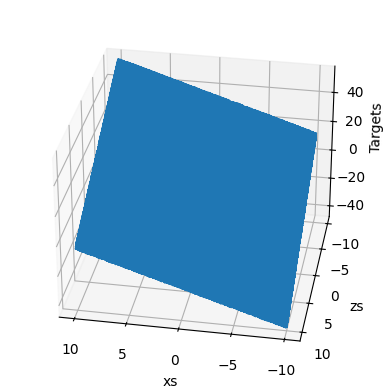

In [4]:

targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.plot(xs,zs,targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

In [5]:
init_range= 0.1
weights = np.random.uniform(low=-init_range,high=init_range,size=(2,1))
biases = np.random.uniform(low=-init_range,high=init_range,size=1)
print(weights,biases)


[[ 0.04834135]
 [-0.03818936]] [-0.02412574]


In [6]:
targets = targets.reshape(observations,1)
eta = 0.001
for i in range (100):
  outputs = np.dot(inputs,weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas **2)/2/observations
  print(loss)

  deltas_scaled = deltas/observations
  weights = weights - eta * np.dot(inputs.T,deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)


222.84185075427922
209.03341394824903
196.1294406670715
184.07058580137408
172.8013983005046
162.2700656544291
152.4281751421074
143.23049074616537
134.63474470587929
126.60144274793964
119.09368209749158
112.07698143083734
105.51912198621937
99.38999910051638
93.66148348772833
88.30729162001668
83.3028646140137
78.6252550643036
74.25302130260229
70.16612859537871
66.34585682463478
62.77471422643364
59.436356789682776
56.315512943759245
53.3979131879365
50.67022433834376
48.1199880894671
45.735563607082895
43.506073888090405
41.42135564007028
39.47191244961204
37.648871023610866
35.94394030189277
34.349373252758994
32.8579311754034
31.462850344708205
30.15781084471725
28.936907447171468
27.79462240091482
26.72580000678454
25.725622860826654
24.789589656365635
23.913494442640683
23.09340724443206
22.325655953373225
21.606809407504173
20.933661581096548
20.303216811897716
19.712675997720964
19.159423698776056
18.641016086307978
18.155169682011277
17.69975083633153
17.272765897170295
16.8

In [7]:
print(weights, biases)

[[ 1.93451384]
 [-2.90195936]] [0.45501295]


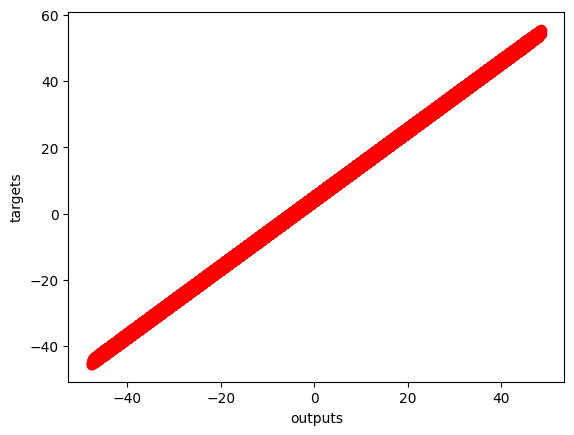

In [8]:
plt.scatter(outputs, targets, color='red')



plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()